In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os # to use operating system dependent functionality
import librosa # to extract speech features
import wave # read and write WAV files
import matplotlib.pyplot as plt # to generate the visualizations

# MLP Classifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# LSTM Classifier
import keras
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import RMSprop

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def extract_mfcc(wav_file_name):
    #This function extracts mfcc features and obtain the mean of each dimension
    #Input : path_to_wav_file
    #Output: mfcc_features'''
    y, sr = librosa.load(wav_file_name)
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T,axis=0)

    return mfccs

In [ ]:
!unzip '/content/drive/MyDrive/speech-emotion-recognition-ravdess-data.zip' -d '/content/RAVDESS_ORG'

In [ ]:
##### load radvess speech data #####
radvess_speech_labels = [] # to save extracted label/file
ravdess_speech_data = [] # to save extracted features/file
for dirname, _, filenames in os.walk('/content/RAVDESS_ORG2'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
        radvess_speech_labels.append(int(filename[7:8]) - 1) # the index 7 and 8 of the file name represent the emotion label
        wav_file_name = os.path.join(dirname, filename)
        ravdess_speech_data.append(extract_mfcc(wav_file_name)) # extract MFCC features/file

print("Finish Loading the Dataset")

Finish Loading the Dataset


In [ ]:
!unzip '/content/ravdess-emotional-speech-audio' -d '/content/RAVDESS_ORG2'

Archive:  /content/ravdess-emotional-speech-audio.zip
replace /content/RAVDESS_ORG2/Actor_01/03-01-01-01-01-01-01.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-02-01-02-02-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-02-02-01-01-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-02-02-01-02-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-02-02-02-01-01.wav  
  inflating: /content/RAVDESS_ORG2/Actor_01/03-01-02-02-02-0

In [ ]:
#### convert data and label to array
ravdess_speech_data_array = np.asarray(ravdess_speech_data) # convert the input to an array
ravdess_speech_label_array = np.array(radvess_speech_labels)
ravdess_speech_label_array.shape # get tuple of array dimensions

#### make categorical labels
labels_categorical = to_categorical(ravdess_speech_label_array) # converts a class vector (integers) to binary class matrix
labels_categorical.shape

(2880, 8)

In [ ]:
ravdess_speech_data_array.shape

(2880, 40)

In [ ]:
x_train,x_test,y_train,y_test= train_test_split(np.array(ravdess_speech_data_array),labels_categorical, test_size=0.20, random_state=9)


In [ ]:

# Split the training, validating, and testing sets
number_of_samples = ravdess_speech_data_array.shape[0]
training_samples = int(number_of_samples * 0.8)
validation_samples = int(number_of_samples * 0.1)
test_samples = int(number_of_samples * 0.1)

In [ ]:

# Define the LSTM model
def create_model_LSTM():
    model = Sequential()
    model.add(LSTM(128, return_sequences=False, input_shape=(40, 1)))
    model.add(Dense(64))
    model.add(Dropout(0.4))
    model.add(Activation('relu'))
    model.add(Dense(32))
    model.add(Dropout(0.4))
    model.add(Activation('relu'))
    model.add(Dense(8))
    model.add(Activation('softmax'))

    # Configures the model for training
    model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
    return model

In [ ]:
w = np.expand_dims(ravdess_speech_data_array[:training_samples],-1)


In [ ]:
w.shape


(2304, 40, 1)

In [ ]:
### train using LSTM model
model_A = create_model_LSTM()
history = model_A.fit(np.expand_dims(ravdess_speech_data_array[:training_samples],-1), labels_categorical[:training_samples], validation_data=(np.expand_dims(ravdess_speech_data_array[training_samples:training_samples+validation_samples], -1), labels_categorical[training_samples:training_samples+validation_samples]), epochs=121, shuffle=True)


Epoch 1/121
72/72 [==============================] - 8s 67ms/step - loss: 2.0637 - accuracy: 0.1450 - val_loss: 2.0241 - val_accuracy: 0.1840
Epoch 2/121
72/72 [==============================] - 5s 74ms/step - loss: 2.0015 - accuracy: 0.2036 - val_loss: 1.9492 - val_accuracy: 0.2500
Epoch 3/121
72/72 [==============================] - 4s 50ms/step - loss: 1.9386 - accuracy: 0.2413 - val_loss: 1.9131 - val_accuracy: 0.2743
Epoch 4/121
72/72 [==============================] - 4s 50ms/step - loss: 1.9090 - accuracy: 0.2617 - val_loss: 1.8732 - val_accuracy: 0.2778
Epoch 5/121
72/72 [==============================] - 6s 82ms/step - loss: 1.8886 - accuracy: 0.2713 - val_loss: 1.8387 - val_accuracy: 0.3160
Epoch 6/121
72/72 [==============================] - 4s 52ms/step - loss: 1.8483 - accuracy: 0.2943 - val_loss: 1.8364 - val_accuracy: 0.2708
Epoch 7/121
72/72 [==============================] - 4s 52ms/step - loss: 1.8445 - accuracy: 0.2817 - val_loss: 1.8124 - val_accuracy: 0.2951
Epoch 

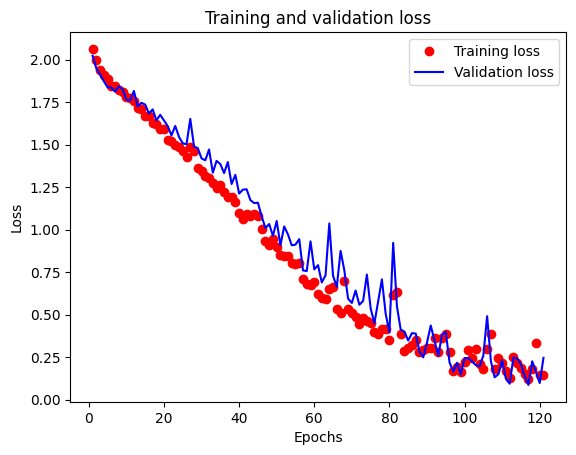

In [ ]:
### loss plots using LSTM model
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

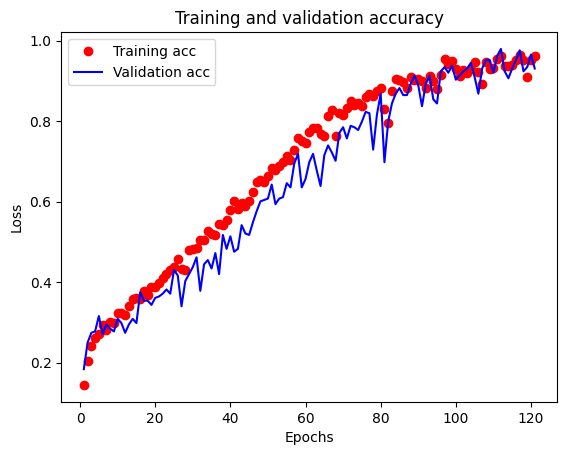

In [ ]:
### accuracy plots using LSTM model
plt.clf()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'ro', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
### evaluate using model A
model_A.evaluate(np.expand_dims(ravdess_speech_data_array[training_samples + validation_samples:], -1), labels_categorical[training_samples + validation_samples:])


9/9 [==============================] - 0s 24ms/step - loss: 0.1862 - accuracy: 0.9479


[0.18617571890354156, 0.9479166865348816]

In [ ]:

emotions={1 : 'neutral', 2 : 'calm', 3 : 'happy', 4 : 'sad', 5 : 'angry', 6 : 'fearful', 7 : 'disgust', 8 : 'surprised'}
def predict(wav_filepath):
  test_point=extract_mfcc(wav_filepath)
  test_point=np.reshape(test_point,newshape=(1,40,1))
  predictions=model_A.predict(test_point)
  print(emotions[np.argmax(predictions[0])+1])

In [ ]:
predict('/content/drive/MyDrive/SERDATABASES/CREMA_AUDIO_EXAMPLES/1001_IEO_DIS_HI.wav')


1/1 [==============================] - 0s 44ms/step
angry


In [ ]:
model_A.save('mymodel_LMS.h5')